In [1]:
!apt-get update
!apt-get install -y tesseract-ocr tesseract-ocr-ind
!pip install pytesseract langdetect

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,286 kB]
Get:14 https

In [21]:
import pandas as pd
import cv2
import numpy as np
import pytesseract
from collections import Counter
from langdetect import detect
from tqdm import tqdm
import matplotlib.pyplot as plt
import re
import zipfile


from collections import Counter
from langdetect import detect
from tqdm import tqdm
from PIL import Image


pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

In [3]:
df = pd.read_csv("/content/drive/MyDrive/capstone/dataset/campur indo/dataset_final.csv")

In [4]:
widths = []
heights = []
brightness = []
texts = []
languages = []

for path in tqdm(df['path']):
    try:
        img = cv2.imread(path)

        if img is None:
            continue

        # ===== UKURAN =====
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

        # ===== KUALITAS (BRIGHTNESS) =====
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))

        # ===== OCR =====
        text = pytesseract.image_to_string(img, lang='ind')
        texts.append(text)

        # ===== BAHASA =====
        if text.strip() != "":
            try:
                languages.append(detect(text))
            except:
                pass

    except:
        continue

100%|██████████| 404/404 [15:17<00:00,  2.27s/it]


In [26]:
print("=== UKURAN GAMBAR ===")
print("Lebar rata-rata :", int(np.mean(widths)))
print("Tinggi rata-rata:", int(np.mean(heights)))

print("\n=== KUALITAS GAMBAR ===")
print("Brightness rata-rata:", round(np.mean(brightness), 2))

print("\n=== BAHASA ===")
print(Counter(languages))

word_counts = [len(t.split()) for t in texts if t.strip() != ""]

print("\n=== PANJANG TEKS ===")
print("Rata-rata jumlah kata:", int(np.mean(word_counts)))

all_words = " ".join(texts).split()
counter = Counter(all_words)

print("\n=== NOISE PALING SERING ===")
print(counter.most_common(10))

=== UKURAN GAMBAR ===
Lebar rata-rata : 512
Tinggi rata-rata: 512

=== KUALITAS GAMBAR ===
Brightness rata-rata: 223.44

=== BAHASA ===
Counter({'en': 220, 'id': 85, 'so': 11, 'tl': 8, 'sk': 7, 'pt': 7, 'de': 6, 'sw': 3, 'nl': 3, 'hu': 3, 'pl': 2, 'vi': 2, 'fi': 2, 'af': 2, 'hr': 1, 'sv': 1, 'ro': 1, 'cy': 1, 'et': 1, 'da': 1, 'lt': 1})

=== PANJANG TEKS ===
Rata-rata jumlah kata: 61

=== NOISE PALING SERING ===
[('Total', 289), (':', 241), ('GST', 239), ('1', 225), ('2', 192), ('—', 150), ('RM', 139), ('Tax', 139), ('-', 138), ('JALAN', 120)]


In [25]:
print("=== UKURAN GAMBAR ===")
print("Lebar rata-rata :", int(np.mean(widths)))
print("Tinggi rata-rata:", int(np.mean(heights)))

print("\n=== KUALITAS GAMBAR ===")
print("Brightness rata-rata:", round(np.mean(brightness), 2))

print("\n=== BAHASA ===")
print(Counter(languages))

=== UKURAN GAMBAR ===
Lebar rata-rata : 512
Tinggi rata-rata: 512

=== KUALITAS GAMBAR ===
Brightness rata-rata: 223.44

=== BAHASA ===
Counter({'en': 220, 'id': 85, 'so': 11, 'tl': 8, 'sk': 7, 'pt': 7, 'de': 6, 'sw': 3, 'nl': 3, 'hu': 3, 'pl': 2, 'vi': 2, 'fi': 2, 'af': 2, 'hr': 1, 'sv': 1, 'ro': 1, 'cy': 1, 'et': 1, 'da': 1, 'lt': 1})


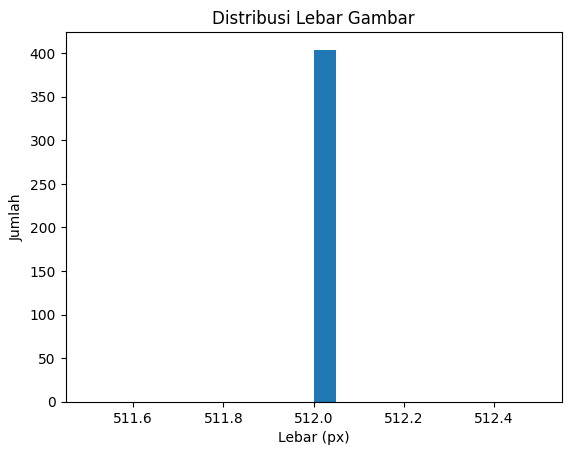

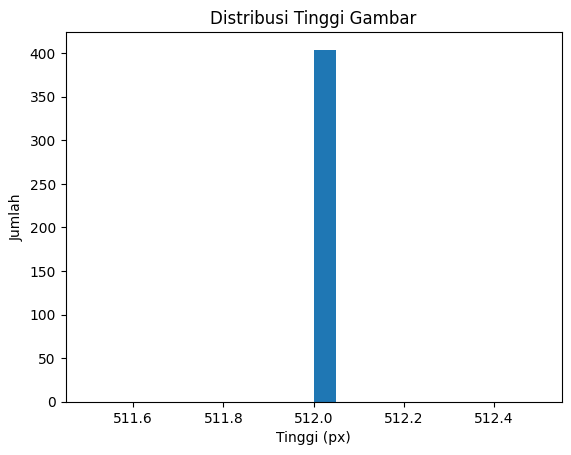

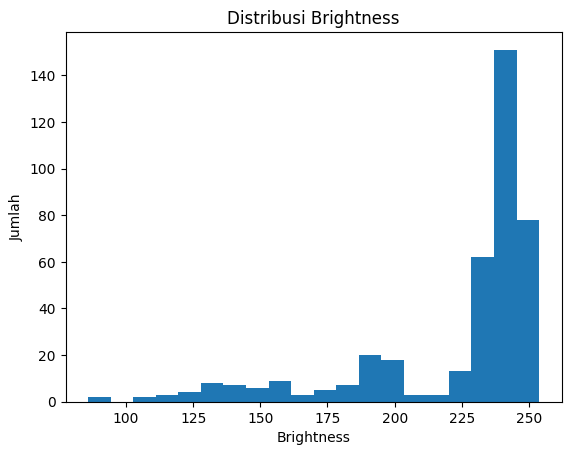

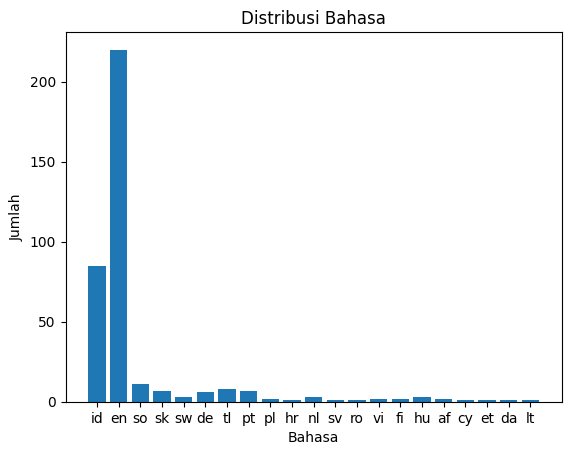

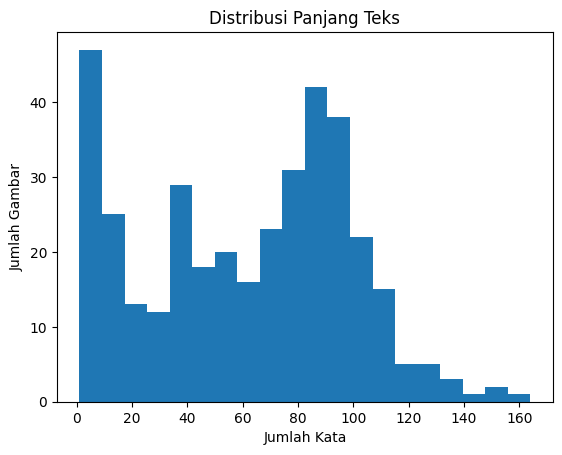


=== NOISE SETELAH CLEANING ===
[('.', 2187), ('-', 1090), (':', 1021), (',', 480)]

=== CONTOH OCR ===

SEBELUM:
 

Itam Kunjungan

 

A-


SESUDAH:
itam kunjungan a-


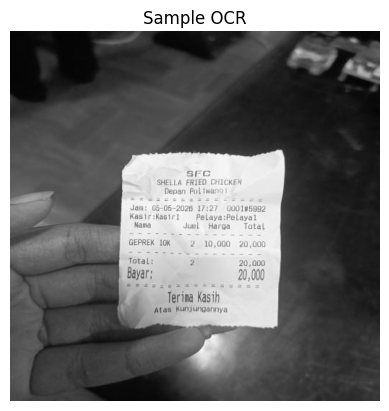


TEXT HASIL OCR:
itam kunjungan a-


In [19]:
if len(widths) == 0:
    print("Data kosong! Pastikan proses EDA sudah dijalankan.")
else:

    # =========================
    # VISUALISASI
    # =========================

    # Lebar
    plt.figure()
    plt.hist(widths, bins=20)
    plt.title("Distribusi Lebar Gambar")
    plt.xlabel("Lebar (px)")
    plt.ylabel("Jumlah")
    plt.show()

    # Tinggi
    plt.figure()
    plt.hist(heights, bins=20)
    plt.title("Distribusi Tinggi Gambar")
    plt.xlabel("Tinggi (px)")
    plt.ylabel("Jumlah")
    plt.show()

    # Brightness
    plt.figure()
    plt.hist(brightness, bins=20)
    plt.title("Distribusi Brightness")
    plt.xlabel("Brightness")
    plt.ylabel("Jumlah")
    plt.show()

    # =========================
    # BAHASA (FIX ERROR DI SINI)
    # =========================
    if len(languages) > 0:
        lang_count = Counter(languages)

        plt.figure()
        plt.bar(list(lang_count.keys()), list(lang_count.values()))
        plt.title("Distribusi Bahasa")
        plt.xlabel("Bahasa")
        plt.ylabel("Jumlah")
        plt.show()
    else:
        print("Data bahasa kosong!")

    # =========================
    # PANJANG TEKS
    # =========================
    if len(word_counts) > 0:
        plt.figure()
        plt.hist(word_counts, bins=20)
        plt.title("Distribusi Panjang Teks")
        plt.xlabel("Jumlah Kata")
        plt.ylabel("Jumlah Gambar")
        plt.show()
    else:
        print("Word count kosong!")

    # =========================
    # CLEANING OCR
    # =========================
    def clean_text(text):
        text = text.lower()
        text = re.sub(r'[^\w\s.,:-]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    cleaned_texts = [clean_text(t) for t in texts if t.strip() != ""]

    # =========================
    # NOISE SETELAH CLEANING
    # =========================
    if len(cleaned_texts) > 0:
        noise_clean = re.findall(r'[^\w\s]', " ".join(cleaned_texts))
        noise_counter_clean = Counter(noise_clean)

        print("\n=== NOISE SETELAH CLEANING ===")
        print(noise_counter_clean.most_common(10))
    else:
        print("Tidak ada teks setelah cleaning!")

    # =========================
    # PERBANDINGAN OCR
    # =========================
    if len(texts) > 0 and len(cleaned_texts) > 0:
        print("\n=== CONTOH OCR ===")
        print("\nSEBELUM:")
        print(texts[0])

        print("\nSESUDAH:")
        print(cleaned_texts[0])
    else:
        print("Tidak ada sample OCR!")

    # =========================
    # TAMPILKAN SAMPLE GAMBAR
    # =========================
    def show_ocr_sample(index=0):
        if index >= len(df):
            print("Index melebihi jumlah data")
            return

        img_path = df['path'][index]

        try:
            img = Image.open(img_path)

            plt.figure()
            plt.imshow(img)
            plt.title("Sample OCR")
            plt.axis('off')
            plt.show()

            if index < len(cleaned_texts):
                print("\nTEXT HASIL OCR:")
                print(cleaned_texts[index])
            else:
                print("Tidak ada OCR untuk gambar ini")

        except:
            print("Gagal membuka gambar")

    show_ocr_sample(0)